# Cell2Cell Telecom — Data Cleaning & Preprocessing


## 1. Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries done')

Libraries done


## 2. Load the Data

In [24]:
df_raw = pd.read_csv('cell2celltrain.csv')

print(f'Shape: {df_raw.shape}')
print(f'Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}')
df_raw.head()

Shape: (51047, 58)
Rows: 51,047   Columns: 58


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.00,22.00,0.25,0.00,0.00,-157.00,-19.00,0.70,0.70,6.30,0.00,0.00,97.20,0.00,0.00,58.00,24.00,1.30,0.00,0.30,61,2,1,SEAPOR503,2.00,2.00,361.00,62.00,0.00,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.00,17.00,0.00,0.00,0.00,-4.00,0.00,0.30,0.00,2.70,0.00,0.00,0.00,0.00,0.00,5.00,1.00,0.30,0.00,0.00,58,1,1,PITHOM412,2.00,1.00,1504.00,40.00,42.00,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.00,38.00,0.00,0.00,0.00,-2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.30,0.00,1.30,3.70,0.00,0.00,0.00,60,1,1,MILMIL414,1.00,1.00,1812.00,26.00,26.00,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.00,75.00,1.24,0.00,0.00,157.00,8.10,52.00,7.70,76.00,4.30,1.30,200.30,370.30,147.00,555.70,303.70,59.70,0.00,22.70,59,2,2,PITHOM412,9.00,4.00,458.00,30.00,0.00,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.00,17.00,0.00,0.00,0.00,0.00,-0.20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,53,2,2,OKCTUL918,4.00,3.00,852.00,46.00,54.00,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


## 3. Data Exploration

In [25]:
print('Column data types:')
print(df_raw.dtypes.value_counts())
print()

# numeric / categorical columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Numeric columns:     {len(numeric_cols)}')
print(f'Categorical columns: {len(categorical_cols)}')
print(f'Categorical: {categorical_cols}')

Column data types:
float64    26
object     23
int64       9
Name: count, dtype: int64

Numeric columns:     35
Categorical columns: 23
Categorical: ['Churn', 'ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']


Churn distribution:
  No: 36,336 (71.2%)
  Yes: 14,711 (28.8%)


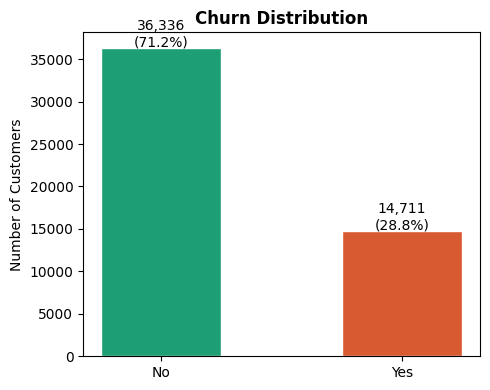

In [26]:
# Target variable distribution
churn_counts = df_raw['Churn'].value_counts()
churn_pct = df_raw['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
for label in churn_counts.index:
    print(f'  {label}: {churn_counts[label]:,} ({churn_pct[label]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#1D9E75', '#D85A30']
ax.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', width=0.5)
ax.set_title('Churn Distribution', fontweight='bold')
ax.set_ylabel('Number of Customers')
for i, (label, val) in enumerate(churn_counts.items()):
    ax.text(i, val + 200, f'{val:,}\n({churn_pct[label]:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Missing Value 

In [27]:
# how much missing values per column
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f'Columns with missing values: {len(missing)}')
print()

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': (missing / len(df_raw) * 100).round(2)
})
print(missing_df)

Columns with missing values: 14

                       Missing Count  Missing %
AgeHH1                           909       1.78
AgeHH2                           909       1.78
PercChangeMinutes                367       0.72
PercChangeRevenues               367       0.72
MonthlyRevenue                   156       0.31
MonthlyMinutes                   156       0.31
TotalRecurringCharge             156       0.31
DirectorAssistedCalls            156       0.31
OverageMinutes                   156       0.31
RoamingCalls                     156       0.31
ServiceArea                       24       0.05
Handsets                           1       0.00
HandsetModels                      1       0.00
CurrentEquipmentDays               1       0.00


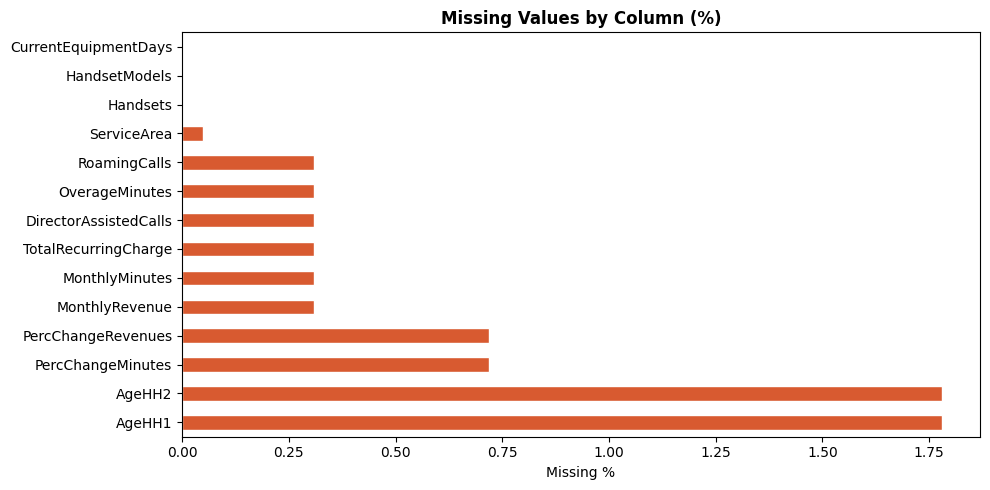

In [28]:
# plot of missing values
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='#D85A30', edgecolor='white')
    ax.set_title('Missing Values by Column (%)', fontweight='bold')
    ax.set_xlabel('Missing %')
    plt.tight_layout()
    plt.show()
else:
    print('No missing')

## 5. HandsetPrice column


In [29]:
#  HandsetPrice
print('HandsetPrice samples:')
print(df_raw['HandsetPrice'].value_counts().head(10))
print()
print(f"'Unknown' entries: {(df_raw['HandsetPrice'] == 'Unknown').sum():,}")

HandsetPrice samples:
HandsetPrice
Unknown    28982
30          7328
150         4115
130         2105
80          1960
10          1928
60          1776
200         1266
100         1235
40           249
Name: count, dtype: int64

'Unknown' entries: 28,982


In [30]:
df = df_raw.copy()

# 'Unknown' -> NaN, and converting to numeric
df['HandsetPrice'] = df['HandsetPrice'].replace('Unknown', np.nan)
df['HandsetPrice'] = pd.to_numeric(df['HandsetPrice'], errors='coerce')

# filling missing HandsetPrice with median
median_price = df['HandsetPrice'].median()
df['HandsetPrice'] = df['HandsetPrice'].fillna(median_price)

print(f'missing after fix: {df["HandsetPrice"].isnull().sum()}')
print(f'HandsetPrice filled values: {median_price:.2f}')

missing after fix: 0
HandsetPrice filled values: 60.00


## 6. Drop Unnecessary Columns

In [31]:
# dropped CustomerID, no need, why not)
if 'CustomerID' in df.columns:
    df.drop(columns=['CustomerID'], inplace=True)
    print('CustomerID column dropped.')

print(f'Shape of dataset after drop: {df.shape}')

CustomerID column dropped.
Shape of dataset after drop: (51047, 57)


## 7. Encode Categorical Variables

Inputs should be numeric, so using Label Encoding for these categorical columns.


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# target: Yes -> 1, No -> 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print(f"Target encoded — Churn rate: {df['Churn'].mean():.1%}")

# Encode categorical columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'\nEncoding {len(cat_cols)} categorical columns: {cat_cols}')

for col in cat_cols:
    df[col] = df[col].astype(str).fillna('Unknown')
    df[col] = le.fit_transform(df[col])

print('\nColumns encoded.')

Target encoded — Churn rate: 28.8%

Encoding 21 categorical columns: ['ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']

Columns encoded.


## 8. Fill Some Remaining Missing Values

In [33]:
# Fill NaN values with column median
remaining_missing = df.isnull().sum().sum()
print(f'Total missing values before: {remaining_missing}')

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f'Total missing values after:  {df.isnull().sum().sum()}')

Total missing values before: 3491
Total missing values after:  0


## 9. Basic Statistics of Cleaned Data

In [34]:
print(f'Final dataset shape: {df.shape}')
print(f'Churn rate: {df["Churn"].mean():.1%}')
print()
df.describe().T[['mean', 'std', 'min', '50%', 'max']].head(20)

Final dataset shape: (51047, 57)
Churn rate: 28.8%



,mean,std,min,50%,max
Churn,0.29,0.45,0.00,0.00,1.00
MonthlyRevenue,58.80,44.44,-6.17,48.46,1223.38
MonthlyMinutes,525.17,529.13,0.00,366.00,7359.00
TotalRecurringCharge,46.82,23.81,-11.00,45.00,400.00
DirectorAssistedCalls,0.89,2.23,0.00,0.25,159.39
OverageMinutes,39.91,96.46,0.00,3.00,4321.00
RoamingCalls,1.23,9.80,0.00,0.00,1112.40
PercChangeMinutes,-11.50,256.59,-3875.00,-5.00,5192.00
PercChangeRevenues,-1.19,39.43,-1107.70,-0.30,2483.50
DroppedCalls,6.01,9.04,0.00,3.00,221.70


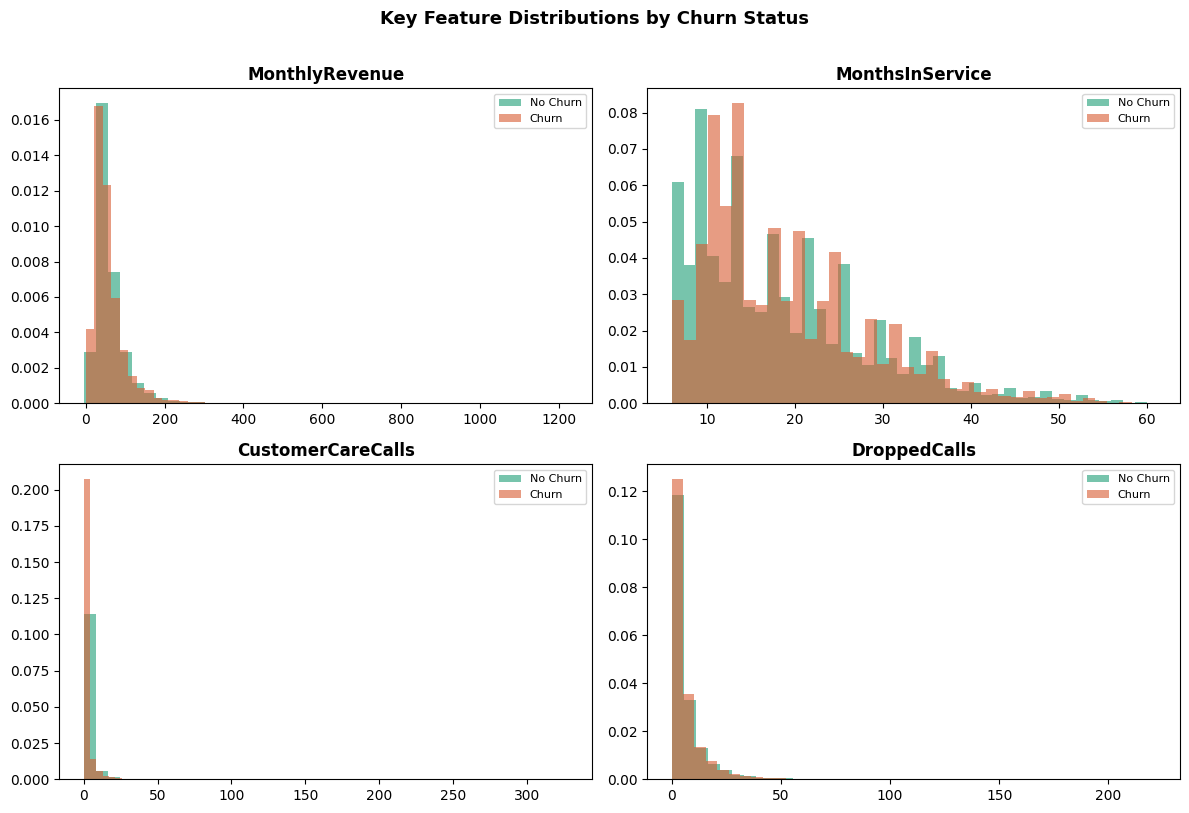

In [35]:
# key feature distributions split by churn
key_features = ['MonthlyRevenue', 'MonthsInService', 'CustomerCareCalls', 'DroppedCalls']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    no_churn = df[df['Churn'] == 0][feat]
    yes_churn = df[df['Churn'] == 1][feat]
    axes[i].hist(no_churn, bins=40, alpha=0.6, color='#1D9E75', label='No Churn', density=True)
    axes[i].hist(yes_churn, bins=40, alpha=0.6, color='#D85A30', label='Churn', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Key Feature Distributions by Churn Status', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Save final Dataset

In [36]:
df.to_csv('clean_train.csv', index=False)
print(f'Clean dataset: clean_train.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns[:10])} ... ({df.shape[1]} total)')

Clean dataset: clean_train.csv
Shape: (51047, 57)
Columns: ['Churn', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls'] ... (57 total)
